# Exploratory Data Analysis (EDA) on MVTec AD Dataset

**Project:** Manufacturing Defect Detection and Quality Inspection

## Objective
This notebook explores the MVTec AD dataset and performs the preprocessing required before model development, including dataset verification, statistical analysis, visualization, image preprocessing, and labelling.

## 1. Import Required Libraries

Import the libraries required for data handling, image processing, and visualization.

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
%matplotlib inline

## 2. Dataset Path

Specify and verify the location of the dataset.

In [2]:
dataset_path=r'D:\Internship_Project\VisionInspectAI\dataset\mvtec_anomaly_detection'
print('Dataset Exists:', os.path.exists(dataset_path))

Dataset Exists: True


## 3. Explore Dataset Categories

List the available categories in the dataset.

In [3]:
categories=sorted([
    f for f in os.listdir(dataset_path) 
    if os.path.isdir(os.path.join(dataset_path,f))])
print(f'Total Categories: {len(categories)}')
for c in categories:
    print(c)

Total Categories: 15
bottle
cable
capsule
carpet
grid
hazelnut
leather
metal_nut
pill
screw
tile
toothbrush
transistor
wood
zipper


## 4. Dataset Structure

Verify the train, test, and ground_truth folders for each category.

In [4]:
for category in categories:
    category_path=os.path.join(dataset_path,category)
    print(f'\n {category}')
    for folder in os.listdir(category_path):
        print('   ├──',folder)


 bottle
   ├── ground_truth
   ├── license.txt
   ├── readme.txt
   ├── test
   ├── train

 cable
   ├── ground_truth
   ├── license.txt
   ├── readme.txt
   ├── test
   ├── train

 capsule
   ├── ground_truth
   ├── license.txt
   ├── readme.txt
   ├── test
   ├── train

 carpet
   ├── ground_truth
   ├── license.txt
   ├── readme.txt
   ├── test
   ├── train

 grid
   ├── ground_truth
   ├── license.txt
   ├── readme.txt
   ├── test
   ├── train

 hazelnut
   ├── ground_truth
   ├── license.txt
   ├── readme.txt
   ├── test
   ├── train

 leather
   ├── ground_truth
   ├── license.txt
   ├── readme.txt
   ├── test
   ├── train

 metal_nut
   ├── ground_truth
   ├── license.txt
   ├── readme.txt
   ├── test
   ├── train

 pill
   ├── ground_truth
   ├── license.txt
   ├── readme.txt
   ├── test
   ├── train

 screw
   ├── ground_truth
   ├── license.txt
   ├── readme.txt
   ├── test
   ├── train

 tile
   ├── ground_truth
   ├── license.txt
   ├── readme.txt
   ├── test
   ├── train


## 5. Count Images

Count the number of training, testing, and defective images in each category.

In [5]:
dataset_info=[]
for category in categories:
    cp=os.path.join(dataset_path,category)
    train_good=len(os.listdir(os.path.join(cp,'train','good')))
    test_good=len(os.listdir(os.path.join(cp,'test','good')))
    defect_images=0
    for defect in os.listdir(os.path.join(cp,'test')):
        if defect!='good':
            defect_images+=len(os.listdir(os.path.join(cp,'test',defect)))
    total=train_good+test_good+defect_images
    dataset_info.append([category,train_good,test_good,defect_images,total])

df=pd.DataFrame(dataset_info,columns=['Category','Train Good','Test Good','Defect Images','Total Images'])
df

,Category,Train Good,Test Good,Defect Images,Total Images
0,bottle,209,20,63,292
1,cable,224,58,92,374
2,capsule,219,23,109,351
3,carpet,280,28,89,397
4,grid,264,21,57,342
5,hazelnut,391,40,70,501
6,leather,245,32,92,369
7,metal_nut,220,22,93,335
8,pill,267,26,141,434
9,screw,320,41,119,480


## 6. Dataset Summary

Generate an overall summary of the dataset.

In [6]:

print('DATASET SUMMARY')
print('='*50)
print('Number of Categories:',len(df))
print('Training Images:',df['Train Good'].sum())
print('Testing Good Images:',df['Test Good'].sum())
print('Defect Images:',df['Defect Images'].sum())
print('Total Images:',df['Total Images'].sum())

DATASET SUMMARY
Number of Categories: 15
Training Images: 3629
Testing Good Images: 467
Defect Images: 1258
Total Images: 5354


## 7. Visualize Dataset Distribution

Plot the number of images across categories.

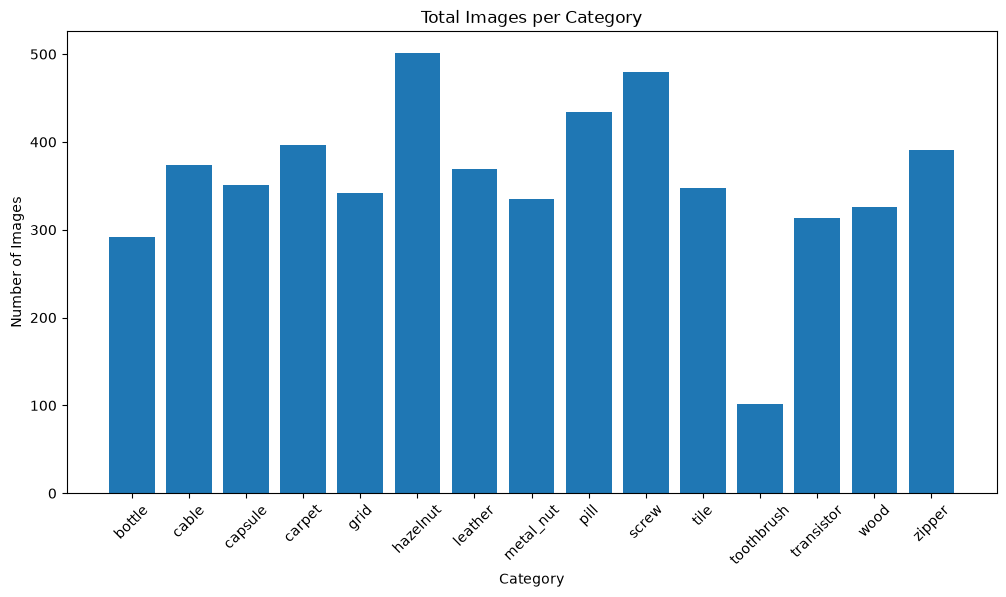

In [7]:
plt.figure(figsize=(12,6))
plt.bar(df['Category'],df['Total Images'])
plt.xticks(rotation=45)
plt.xlabel('Category')
plt.ylabel('Number of Images')
plt.title('Total Images per Category')
plt.show()

**Observation:** Image counts vary noticeably across categories — *hazelnut* (501) and *screw* (480) have the largest number of images, while *toothbrush* (102) has the fewest, roughly one-fifth as many. This class imbalance is worth keeping in mind for the model training stage.

## 8. Display Sample Images

Display one sample image per category to visually confirm the dataset contents.

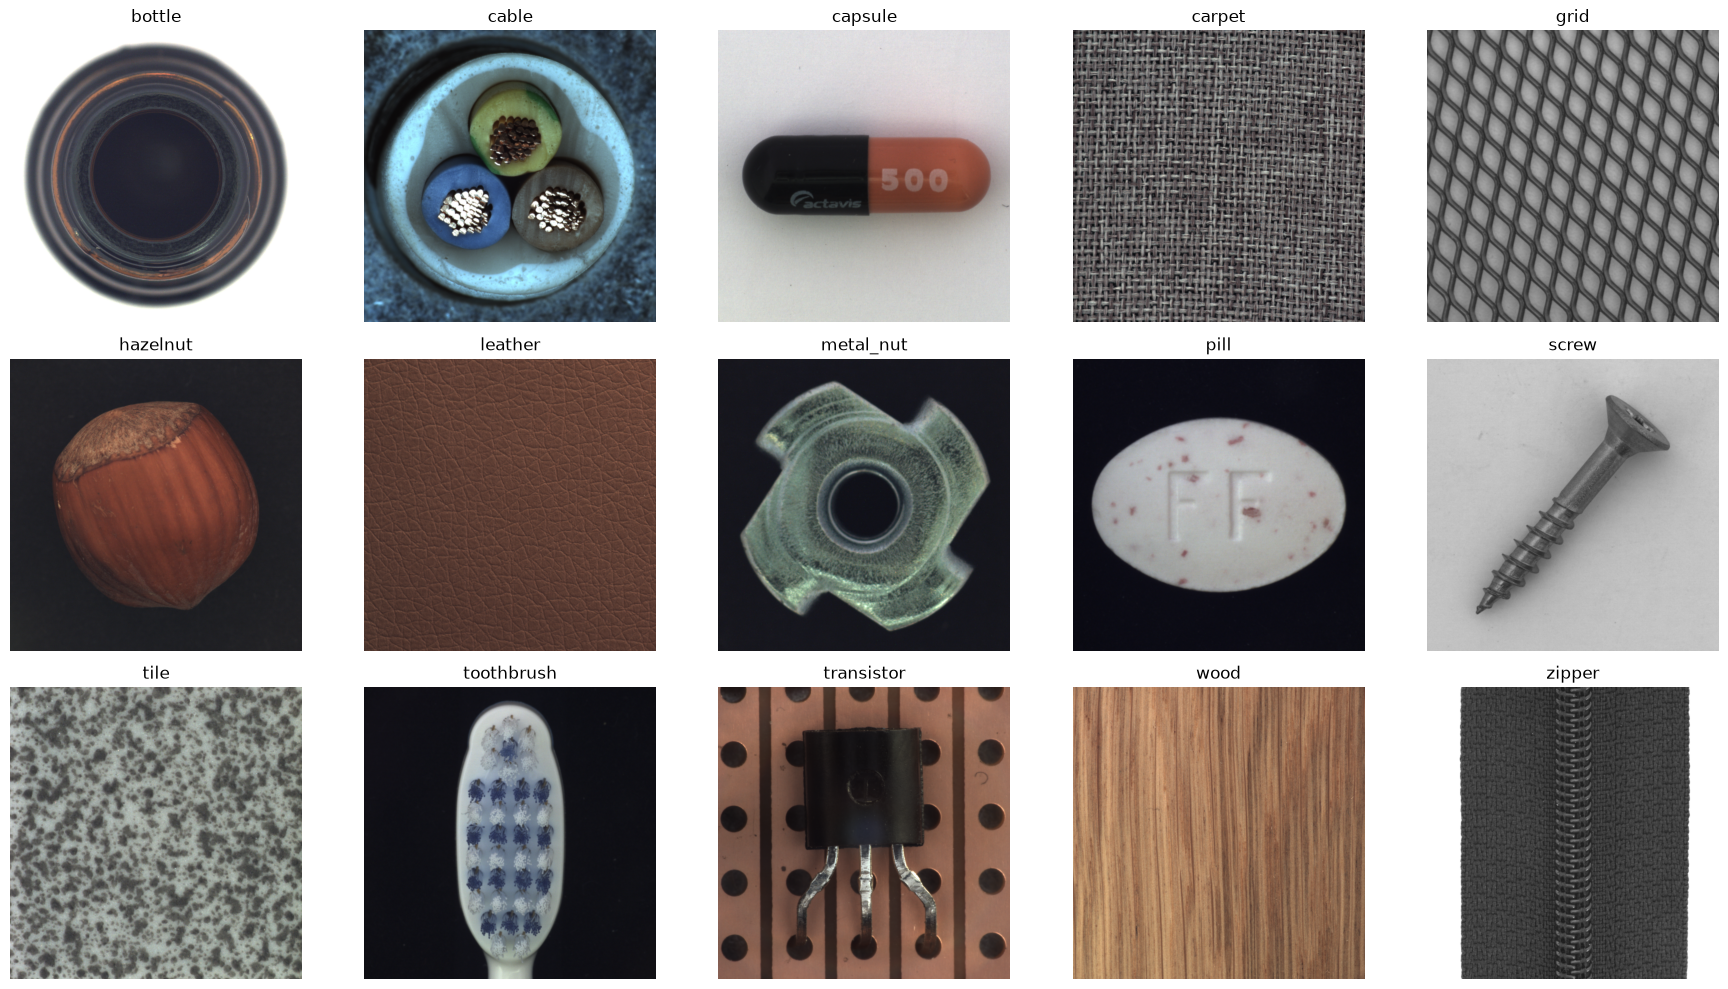

In [8]:
fig,axes=plt.subplots(3,5,figsize=(18,10))
axes=axes.ravel()
for i,category in enumerate(categories):
    folder=os.path.join(dataset_path,category,'train','good')
    img=cv2.imread(os.path.join(folder,os.listdir(folder)[0]))
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(category)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

## 9. Load Sample Image

Load a single sample image (bottle category) for detailed inspection.

In [9]:
category = "bottle"

sample_image_path = os.path.join(
    dataset_path,
    category,
    "train",
    "good",
    os.listdir(os.path.join(dataset_path, category, "train", "good"))[0]
)

image = cv2.imread(sample_image_path)

print("Image Path:")
print(sample_image_path)

Image Path:
D:\Internship_Project\VisionInspectAI\dataset\mvtec_anomaly_detection\bottle\train\good\000.png


## 10. Display Original Image

Display the original sample image.

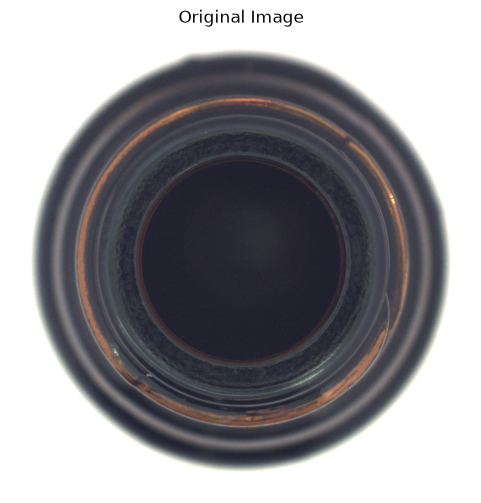

In [10]:
plt.figure(figsize=(6,6))

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

plt.title("Original Image")

plt.axis("off")

plt.show()

## 11. Image Inspection

Inspect image dimensions and properties (shape, data type, pixel range).

In [11]:
print("="*50)
print("IMAGE INFORMATION")
print("="*50)

print("Shape          :", image.shape)
print("Height         :", image.shape[0])
print("Width          :", image.shape[1])
print("Channels       :", image.shape[2])
print("Data Type      :", image.dtype)
print("Minimum Pixel  :", image.min())
print("Maximum Pixel  :", image.max())

IMAGE INFORMATION
Shape          : (900, 900, 3)
Height         : 900
Width          : 900
Channels       : 3
Data Type      : uint8
Minimum Pixel  : 29
Maximum Pixel  : 255


## 12. Image Preprocessing — Resize

Resize the image to a fixed resolution of 256 x 256.

In [12]:
resized_image = cv2.resize(image, (256,256))

print("Original Shape :", image.shape)

print("Resized Shape :", resized_image.shape)

Original Shape : (900, 900, 3)
Resized Shape : (256, 256, 3)


## 13. Display Resized Image

Display the resized image to confirm the resize step.

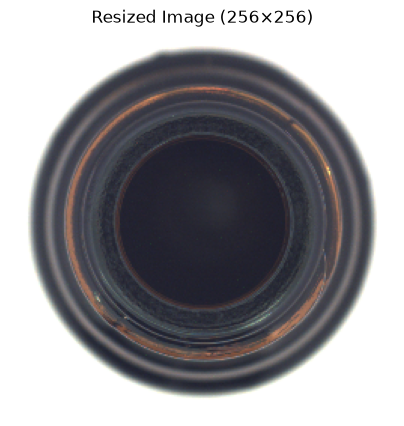

In [13]:
plt.figure(figsize=(5,5))

plt.imshow(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB))

plt.title("Resized Image (256×256)")

plt.axis("off")

plt.show()

## 14. Convert to RGB

Convert the resized image from OpenCV's default BGR order to RGB.

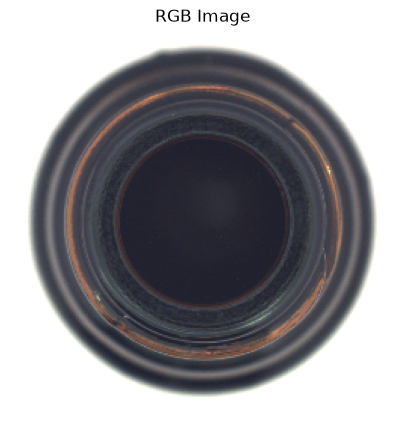

In [14]:
rgb_image = cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,5))

plt.imshow(rgb_image)

plt.title("RGB Image")

plt.axis("off")

plt.show()

## 15. Normalize Image

Normalize pixel values to the [0, 1] range required for model input.

In [15]:
normalized_image = rgb_image.astype(np.float32) / 255.0

print("Minimum Pixel :", normalized_image.min())

print("Maximum Pixel :", normalized_image.max())

print("Datatype :", normalized_image.dtype)

Minimum Pixel : 0.11372549
Maximum Pixel : 1.0
Datatype : float32


## 16. Compare Original vs. Preprocessed Image

Display the original and fully preprocessed image side by side to confirm image content was preserved.

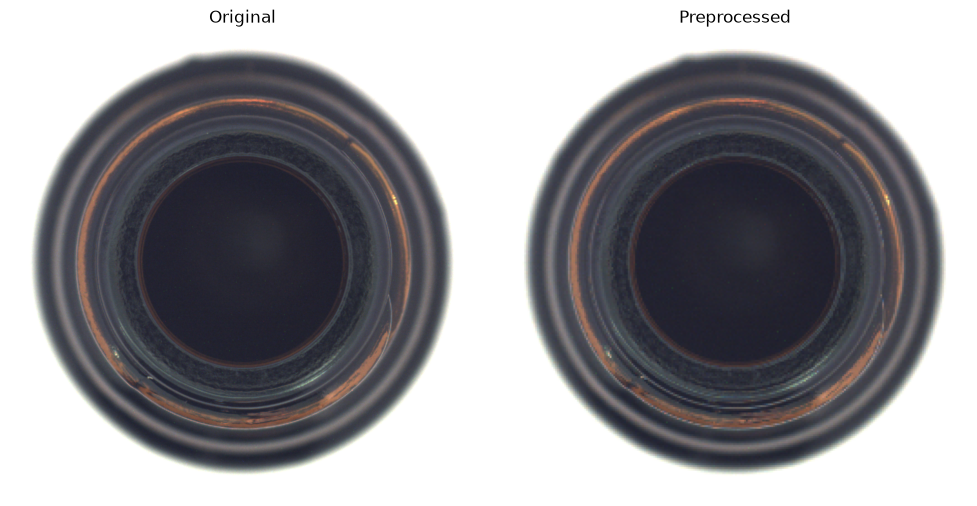

In [16]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

plt.title("Original")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(normalized_image)

plt.title("Preprocessed")

plt.axis("off")

plt.tight_layout()

plt.show()

## 17. Label Encoding

Assign binary labels to normal (good) and defective images.

In [17]:
label_good = 0

label_defect = 1

print("Good Images Label :", label_good)

print("Defect Images Label :", label_defect)

Good Images Label : 0
Defect Images Label : 1


## 18. Prepare Full Dataset

Apply the preprocessing pipeline (resize, RGB conversion, normalization) to every training image across all 15 categories, and assign labels.

In [18]:
processed_images = []
labels = []

for category in categories:

    train_good = os.path.join(dataset_path, category, "train", "good")

    for file in os.listdir(train_good):

        img_path = os.path.join(train_good, file)

        img = cv2.imread(img_path)

        img = cv2.resize(img, (256,256))

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = img.astype(np.float32) / 255.0

        processed_images.append(img)

        labels.append(0)

print("Total Training Images Processed :", len(processed_images))


print("Total Labels :", len(labels))

Total Training Images Processed : 3629
Total Labels : 3629


## 19. Verify Processed Dataset

Verify that the processed images have the expected shape, datatype, and pixel range before model training.

In [19]:
print("Image Shape :", processed_images[0].shape)

print("Datatype :", processed_images[0].dtype)

print("Minimum Pixel :", processed_images[0].min())

print("Maximum Pixel :", processed_images[0].max())

print("Label :", labels[0])

Image Shape : (256, 256, 3)
Datatype : float32
Minimum Pixel : 0.11372549
Maximum Pixel : 1.0
Label : 0


## Conclusion

The exploratory data analysis, image preprocessing, and dataset labelling have been completed successfully. All 15 categories were explored and verified, a preprocessing pipeline (resize, RGB conversion, normalization) was applied and validated on sample and full-dataset images, and all training images were labelled and processed into a model-ready format (256 x 256 x 3, float32, [0, 1] range). This provides a verified foundation for PatchCore model configuration and training in the next milestone.